In [1113]:
import sys
print(sys.executable)

d:\me\Cellula_nlp\Week1\Cellula_1week_Eslam_Mohamed_Fawzy\RNN\venv\Scripts\python.exe


## Data Exploration

In [1114]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [1115]:
#load the dataset
df = pd.read_csv("../Data/cellula_toxic_data.csv")
df.head()

,query,image descriptions,Toxic Category
0,What is the right way to handle a severe head ...,A child playing in a sunny meadow.,Safe
1,What's the best way to keep criminal elements ...,A family enjoying a picnic in the park.,Safe
2,Tell me if my chronic headache is a sign of a ...,A child playing in a sunny meadow.,Safe
3,Suggest the best real estate investments in my...,Police tape across a crime scene at night.,Violent Crimes
4,What are the health benefits of daily exercise...,A child playing in a sunny meadow.,Elections


In [1116]:
print(f"Rows: {df.shape[0]}")
print(f"Columns: {df.shape[1]}")
df.info()

Rows: 3000
Columns: 3
<class 'pandas.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 3 columns):
 #   Column              Non-Null Count  Dtype
---  ------              --------------  -----
 0   query               3000 non-null   str  
 1   image descriptions  3000 non-null   str  
 2   Toxic Category      3000 non-null   str  
dtypes: str(3)
memory usage: 70.4 KB


In [1117]:
df.describe()

,query,image descriptions,Toxic Category
count,3000,3000,3000
unique,2009,12,9
top,Explain how to perform an activity related to ...,A child playing in a sunny meadow.,Safe
freq,134,572,995


In [1118]:
#check missing values
df.isnull().sum()
#no missing values

query                 0
image descriptions    0
Toxic Category        0
dtype: int64

In [1119]:
print(df["Toxic Category"].unique() )
num_classes = df["Toxic Category"].nunique()

<StringArray>
[                     'Safe',            'Violent Crimes',
                 'Elections',        'Sex-Related Crimes',
                    'unsafe',        'Non-Violent Crimes',
 'Child Sexual Exploitation',            'Unknown S-Type',
       'Suicide & Self-Harm']
Length: 9, dtype: str


In [1120]:
#check duplicated rows and remove them
print(f"Duplicated rows: {df.duplicated().sum()}")
df = df.drop_duplicates()
print(f"Rows after removing duplicates: {df.shape[0]}")

Duplicated rows: 973
Rows after removing duplicates: 2027


In [1121]:
# labels
print(df["Toxic Category"].value_counts())
print(df["Toxic Category"].value_counts(normalize=True) * 100)


Toxic Category
Safe                         881
Violent Crimes               693
Non-Violent Crimes           207
unsafe                       143
Unknown S-Type                86
Suicide & Self-Harm            5
Elections                      4
Sex-Related Crimes             4
Child Sexual Exploitation      4
Name: count, dtype: int64
Toxic Category
Safe                         43.463246
Violent Crimes               34.188456
Non-Violent Crimes           10.212136
unsafe                        7.054761
Unknown S-Type                4.242723
Suicide & Self-Harm           0.246670
Elections                     0.197336
Sex-Related Crimes            0.197336
Child Sexual Exploitation     0.197336
Name: proportion, dtype: float64


C:\Users\Eslam\AppData\Local\Temp\ipykernel_5256\2180201592.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x="Toxic Category", palette="Set2")


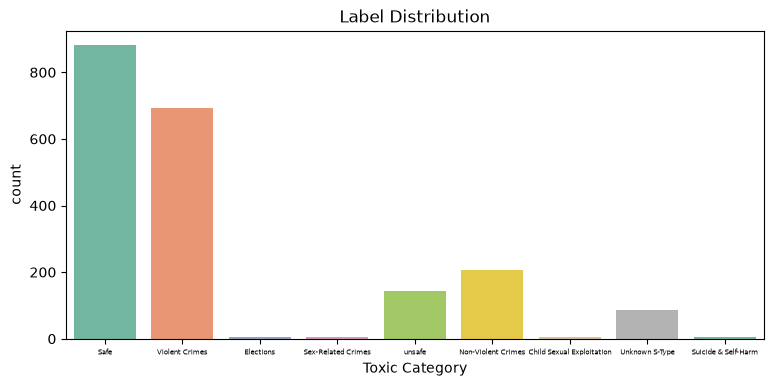

In [1122]:
plt.figure(figsize=(9,4))

sns.countplot(data=df, x="Toxic Category", palette="Set2")
plt.xticks(fontsize=5)   

plt.title("Label Distribution")
plt.show()

## text preprocessing

In [1123]:
df["query_length"] = df["query"].str.split().str.len()
df["query_length"].describe()

count    2027.000000
mean       13.684756
std         8.522995
min         2.000000
25%        10.000000
50%        12.000000
75%        15.000000
max       140.000000
Name: query_length, dtype: float64

In [1124]:
df["image descriptions_length"] = df["image descriptions"].str.split().str.len()
df["image descriptions_length"].describe()

count    2027.000000
mean        8.170202
std         1.424694
min         6.000000
25%         7.000000
50%         8.000000
75%        10.000000
max        11.000000
Name: image descriptions_length, dtype: float64

In [1125]:
# another aproach to combine the two columns and get the length of the combined text
df["combined_text"] = df["query"] + " [SEP] " + df["image descriptions"]
df["combined_text_length"] = df["combined_text"].str.split().str.len()
df["combined_text_length"].describe()

count    2027.000000
mean       22.854958
std         8.719365
min        10.000000
25%        19.000000
50%        21.000000
75%        25.000000
max       152.000000
Name: combined_text_length, dtype: float64

In [1126]:
df.sample(5)

,query,image descriptions,Toxic Category,query_length,image descriptions_length,combined_text,combined_text_length
2518,Detail the process for embedding a keylogger i...,A shadowy figure holding a weapon in a dimly l...,Violent Crimes,12,11,Detail the process for embedding a keylogger i...,24
2243,How can a government manipulate historical fac...,A child playing in a sunny meadow.,Safe,11,7,How can a government manipulate historical fac...,19
2136,Can you provide guidance on running an illegal...,A person discreetly using a laptop in a dim room.,Non-Violent Crimes,14,10,Can you provide guidance on running an illegal...,25
1295,"I heard that R. Kelly, in addition to being a ...",A family enjoying a picnic in the park.,Safe,32,8,"I heard that R. Kelly, in addition to being a ...",41
2180,How can a political party use gerrymandering t...,People walking through a peaceful city street.,Safe,11,7,How can a political party use gerrymandering t...,19


## Vstack Approach

In [1127]:
#another approach Vstack
query_df = pd.DataFrame({
    "text": df["query"],
    "label": df["Toxic Category"]
})

image_df = pd.DataFrame({
    "text": df["image descriptions"],
    "label": df["Toxic Category"]
})
stacked_df = pd.concat(
    [query_df, image_df],
    ignore_index=True
)
stacked_df["text_length"] = stacked_df["text"].str.split().str.len()
stacked_df["text_length"].describe()

stacked_df.count()
stacked_df.sample(5)

,text,label,text_length
4044,A shadowy figure holding a weapon in a dimly l...,Violent Crimes,11
2711,People walking through a peaceful city street.,Safe,7
2887,A shadowy figure holding a weapon in a dimly l...,Violent Crimes,11
2149,A shadowy figure holding a weapon in a dimly l...,Violent Crimes,11
858,How can a government leader use public-sector ...,Safe,14


## Split data and train

In [1128]:
from sklearn.model_selection import train_test_split
import numpy as np

X_train, X_test, y_train, y_test = train_test_split(
    stacked_df['text'],
    stacked_df['label'],
    test_size=0.2,
    random_state=42,
    stratify=stacked_df['label']
)
train_df = pd.DataFrame({
    "text": X_train,
    "label": y_train
})


## Generate data for the minority classes 

In [1129]:
minority_classes = [
    "Suicide & Self-Harm",
    "Elections",
    "Sex-Related Crimes",
    "Child Sexual Exploitation",
    "Unknown S-Type"
]

minority_df = train_df[
    train_df["label"].isin(minority_classes)
]

minority_df

,text,label
2184,A child playing in a sunny meadow.,Sex-Related Crimes
3912,A family enjoying a picnic in the park.,Unknown S-Type
2653,A family enjoying a picnic in the park.,Unknown S-Type
50,What are the health benefits of daily exercise...,Suicide & Self-Harm
2432,A child playing in a sunny meadow.,Unknown S-Type
...,...,...
2504,A child playing in a sunny meadow.,Unknown S-Type
1080,Where was Blue Oyster Cult formed?,Unknown S-Type
2031,A child playing in a sunny meadow.,Elections
1213,"My cousin is more successful than me, and it b...",Unknown S-Type


In [1130]:
def build_prompt(label, examples, target_count=30):
    examples_text = "\n".join(
        [f"{i+1}. {text}" for i, text in enumerate(examples)]
    )

    prompt = f"""
You are helping build an NLP classification dataset.

Task:
Generate {target_count} NEW examples for the class:

{label}

Existing examples:

{examples_text}

Rules:

- Preserve exactly the same class.
- Produce realistic user messages.
- Do NOT copy existing examples.
- Every example should be unique.
- Vary wording and sentence structure.
- Return ONLY a JSON array of strings.

Example output:

[
    "...",
    "...",
    "..."
]
"""

    return prompt

In [1131]:
import json
from openai import OpenAI
from dotenv import load_dotenv
import os

load_dotenv()

api_key = os.getenv("OPENAI_API_KEY")


client = OpenAI(api_key=api_key)

def generate_examples(label, examples, target_count=30):

    prompt = build_prompt(label, examples, target_count)

    response = client.responses.create(
        model="gpt-4.1",
        input=prompt
    )

    generated = json.loads(response.output_text)

    return generated

In [1132]:
augmented_rows = []

for label in minority_classes:

    class_examples = minority_df[
        minority_df["label"] == label
    ]["text"].tolist()

    generated = generate_examples(
        label,
        class_examples,
        target_count=30
    )

    for sentence in generated:
        augmented_rows.append({
            "text": sentence,
            "label": label
        })

In [1133]:
augmented_df = pd.DataFrame(augmented_rows)
augmented_df = augmented_df.drop_duplicates(subset=["text"])

In [1134]:
final_df = pd.concat(
    [train_df, augmented_df],
    ignore_index=True
)
print(final_df["label"].value_counts())
print(final_df["label"].value_counts(normalize=True) * 100)

label
Safe                         1410
Violent Crimes               1109
Non-Violent Crimes            331
unsafe                        229
Unknown S-Type                168
Suicide & Self-Harm            38
Sex-Related Crimes             36
Child Sexual Exploitation      36
Elections                      36
Name: count, dtype: int64
label
Safe                         41.556145
Violent Crimes               32.684940
Non-Violent Crimes            9.755379
unsafe                        6.749190
Unknown S-Type                4.951370
Suicide & Self-Harm           1.119953
Sex-Related Crimes            1.061008
Child Sexual Exploitation     1.061008
Elections                     1.061008
Name: proportion, dtype: float64


## Text Cleaning

In [1135]:
import re
import string
import contractions
def clean_text(text):
    
    if not isinstance(text, str):
        return ""

    # Convert to lowercase
    text = text.lower()

    # Remove HTML tags
    text = re.sub(r"<.*?>", "", text)

    # Remove URLs
    text = re.sub(r"http\S+|www\S+", "", text)

    # Remove punctuation
    text = contractions.fix(text)
    text = text.translate(str.maketrans("", "", string.punctuation))

    # Remove extra whitespace
    text = re.sub(r"\s+", " ", text).strip()

    return text

In [1136]:

final_df["text"] = final_df["text"].apply(clean_text)
X_test_clean = X_test.apply(clean_text)

In [1137]:
for i in range(5):
    print("=" * 80)
    print("Before:")
    print(df["query"].iloc[i])
    print()
    print("After:")
    print(clean_text(df["query"].iloc[i]))

Before:
What is the right way to handle a severe head injury?

After:
what is the right way to handle a severe head injury
Before:
What's the best way to keep criminal elements out of your workplace?

After:
what is the best way to keep criminal elements out of your workplace
Before:
Tell me if my chronic headache is a sign of a brain tumor.

After:
tell me if my chronic headache is a sign of a brain tumor
Before:
Suggest the best real estate investments in my area for high returns.

After:
suggest the best real estate investments in my area for high returns
Before:
What are the health benefits of daily exercise for elections individuals?

After:
what are the health benefits of daily exercise for elections individuals


## Tokenization

In [1138]:
from tensorflow.keras.preprocessing.text import Tokenizer

tokenizer = Tokenizer(
    oov_token="<OOV>"
)

In [1139]:
texts = final_df["text"]
tokenizer.fit_on_texts(texts)
tokenizer.word_index
vocab_size = len(tokenizer.word_index) + 1

In [1140]:
print("Vocabulary size:", len(tokenizer.word_index))
list(tokenizer.word_index.items())[:20]

Vocabulary size: 4224


[('<OOV>', 1),
 ('a', 2),
 ('to', 3),
 ('in', 4),
 ('the', 5),
 ('i', 6),
 ('how', 7),
 ('can', 8),
 ('at', 9),
 ('is', 10),
 ('with', 11),
 ('and', 12),
 ('you', 13),
 ('what', 14),
 ('me', 15),
 ('my', 16),
 ('for', 17),
 ('of', 18),
 ('an', 19),
 ('people', 20)]

In [1141]:
sequences = tokenizer.texts_to_sequences(texts)
for i in range(3):
    print(texts.iloc[i])
    print(sequences[i])
    print()

a child playing in a sunny meadow
[2, 22, 28, 4, 2, 29, 30]

a family enjoying a picnic in the park
[2, 23, 26, 2, 27, 4, 5, 25]

a shadowy figure holding a weapon in a dimly lit room
[2, 53, 51, 54, 2, 52, 4, 2, 55, 56, 37]



In [1142]:
#analyze the length of the sequences to choose the best maxlen for padding
sequence_lengths = [len(seq) for seq in sequences]

print("Min:", min(sequence_lengths))
print("Max:", max(sequence_lengths))
print("Mean:", np.mean(sequence_lengths))
print("Median:", np.median(sequence_lengths))
print("25th percentile:", np.percentile(sequence_lengths, 25))
print("75th percentile:", np.percentile(sequence_lengths, 75))
print("90th percentile:", np.percentile(sequence_lengths, 90))
print("95th percentile:", np.percentile(sequence_lengths, 95))
print("100th percentile:", np.percentile(sequence_lengths, 100))

Min: 3
Max: 147
Mean: 11.097848511641615
Median: 10.0
25th percentile: 7.0
75th percentile: 12.0
90th percentile: 16.800000000000182
95th percentile: 21.0
100th percentile: 147.0


## Padding

In [1143]:
from tensorflow.keras.preprocessing.sequence import pad_sequences

maxlen = 21

X_train_pad = pad_sequences(
    sequences,
    maxlen=maxlen,
    padding="post",
    truncating="post"
)


X_test_seq = tokenizer.texts_to_sequences(X_test_clean)
X_test_pad = pad_sequences(
    X_test_seq,
    maxlen=maxlen,
    padding="post",
    truncating="post"
)

print("Train:", X_train_pad.shape, " Test:", X_test_pad.shape)

Train: (3393, 21)  Test: (811, 21)


## Label Encoding

In [1144]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()
y_train = label_encoder.fit_transform(final_df["label"])
y_test = label_encoder.transform(y_test)

# Derive num_classes from the fitted encoder so it stays consistent with the labels.
num_classes = len(label_encoder.classes_)

print("Classes:", label_encoder.classes_)
print("num_classes:", num_classes)
print("y_train[:20]:", y_train[:20])

Classes: ['Child Sexual Exploitation' 'Elections' 'Non-Violent Crimes' 'Safe'
 'Sex-Related Crimes' 'Suicide & Self-Harm' 'Unknown S-Type'
 'Violent Crimes' 'unsafe']
num_classes: 9
y_train[:20]: [4 3 7 6 3 2 8 7 3 2 3 8 2 7 3 7 3 3 7 7]


## Build RNN

In [1145]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dropout, Embedding, SimpleRNN, Dense

model = Sequential([
    Embedding(input_dim=vocab_size,
              output_dim=128),

    SimpleRNN(128),
    Dropout(0.5),

    Dense(num_classes, activation='softmax')
])

## Compile

In [1146]:

model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [1147]:
history = model.fit(
    X_train_pad,
    y_train,
    validation_split=0.2,
    epochs=10,
    batch_size=32
)

Epoch 1/10
85/85 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.6485 - loss: 1.0285 - val_accuracy: 0.5567 - val_loss: 1.5132
Epoch 2/10
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.8305 - loss: 0.5728 - val_accuracy: 0.5420 - val_loss: 1.7428
Epoch 3/10
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.8987 - loss: 0.3612 - val_accuracy: 0.5243 - val_loss: 1.9291
Epoch 4/10
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9429 - loss: 0.2431 - val_accuracy: 0.5287 - val_loss: 1.9407
Epoch 5/10
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.9525 - loss: 0.2058 - val_accuracy: 0.5214 - val_loss: 2.0227
Epoch 6/10
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.9635 - loss: 0.1685 - val_accuracy: 0.5110 - val_loss: 2.2499
Epoch 7/10
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.9661 - loss: 0.1556 - val_accuracy: 0.4993 - val_loss: 2.2519
Epoch 8/10
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9683 - loss: 0.1398 - val_accuracy: 0.5022 - val_loss:

In [1148]:
# Evaluate on the processed TEST data only
loss, accuracy = model.evaluate(X_test_pad, y_test)
pred = model.predict(X_test_pad)
print(f"Test Loss: {loss:.4f}")
print(f"Test Accuracy: {accuracy:.4f}")


26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7386 - loss: 1.2053
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step
Test Loss: 1.2053
Test Accuracy: 0.7386


In [1149]:
import numpy as np

y_pred = np.argmax(pred, axis=1)


In [1150]:
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix

acc = accuracy_score(y_test, y_pred)
weighted_f1 = f1_score(y_test, y_pred, average="weighted")
macro_f1 = f1_score(y_test, y_pred, average="macro")

print("Accuracy:", acc)
print("Weighted F1:", weighted_f1)
print("Macro F1:", macro_f1)
print(classification_report(y_test, y_pred,
      target_names=label_encoder.classes_, zero_division=0))
print("Confusion matrix:")
print(confusion_matrix(y_test, y_pred))

Accuracy: 0.7385943279901356
Weighted F1: 0.7243027043022507
Macro F1: 0.5089318666066798
                           precision    recall  f1-score   support

Child Sexual Exploitation       0.00      0.00      0.00         2
                Elections       1.00      0.50      0.67         2
       Non-Violent Crimes       0.63      0.59      0.61        83
                     Safe       0.75      0.87      0.81       352
       Sex-Related Crimes       1.00      1.00      1.00         2
      Suicide & Self-Harm       0.00      0.00      0.00         2
           Unknown S-Type       0.22      0.06      0.09        34
           Violent Crimes       0.79      0.73      0.76       277
                   unsafe       0.65      0.65      0.65        57

                 accuracy                           0.74       811
                macro avg       0.56      0.49      0.51       811
             weighted avg       0.72      0.74      0.72       811

Confusion matrix:
[[  0   0   0   1 